Dataset Shape: (30, 8)

===== KPI SUMMARY =====
Total Revenue: 82182.1
Total Profit: 15493.8
Total Orders: 30
Total Customers: 23
Average Order Value: 2739.4
Profit Margin (%): 18.85

===== CUSTOMER SEGMENTS =====
Segment
Medium Value    16
Low Value        4
High Value       3
Name: count, dtype: int64

===== SALES BY CATEGORY =====
Category
Technology         42573.59
Office Supplies    29167.67
Furniture          10440.84
Name: Sales, dtype: float64

===== TOP 10 PRODUCTS =====
Product
Printer     18111.25
Notebook    15948.82
Pen         13218.85
Phone       12618.41
Laptop      11843.93
Table        5227.00
Chair        5213.84
Name: Sales, dtype: float64


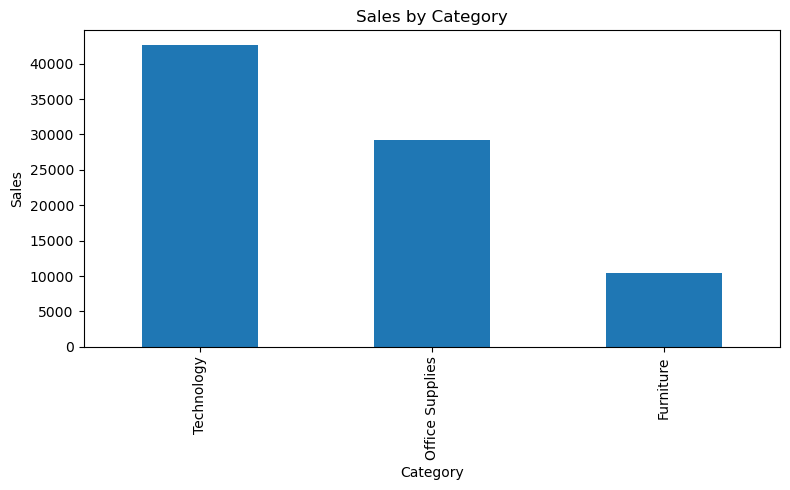

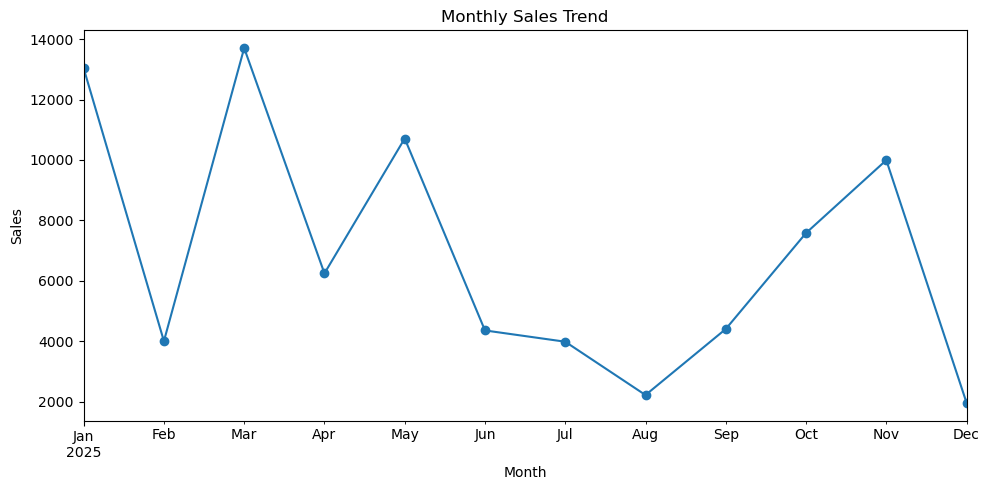

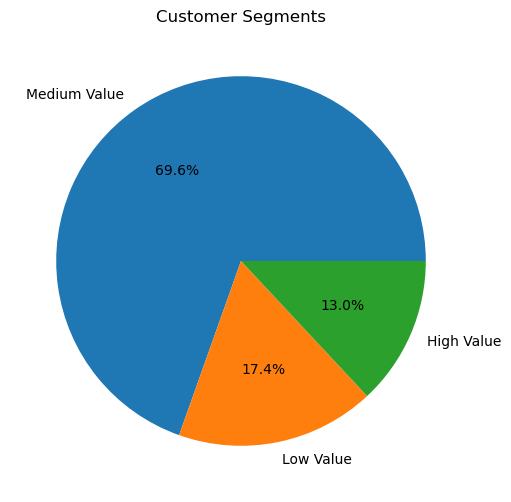

Files exported successfully!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATA

df = pd.read_csv(r"C:\Users\Chaithanya\Desktop\dashboard project\Sales_Dataset.csv")

# DATA CLEANING

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
print("Dataset Shape:", df.shape)

# KPI CALCULATIONS

total_revenue = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_orders = df['Order ID'].nunique()

total_customers = df['Customer ID'].nunique()

average_order_value = total_revenue / total_orders

profit_margin = (total_profit / total_revenue) * 100

print("\n===== KPI SUMMARY =====")
print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))
print("Profit Margin (%):", round(profit_margin, 2))

# CUSTOMER SEGMENTATION

customer_sales = (
    df.groupby('Customer ID')['Sales']
    .sum()
    .reset_index()
)

customer_sales['Segment'] = pd.cut(
    customer_sales['Sales'],
    bins=[0, 1000, 5000, float('inf')],
    labels=['Low Value', 'Medium Value', 'High Value']
)

print("\n===== CUSTOMER SEGMENTS =====")
print(customer_sales['Segment'].value_counts())

# SALES BY CATEGORY

sales_by_category = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print("\n===== SALES BY CATEGORY =====")
print(sales_by_category)

# MONTHLY SALES TREND

df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

# TOP  PRODUCTS

top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n===== TOP 10 PRODUCTS =====")
print(top_products)

# VISUALIZATION 1
# SALES BY CATEGORY

plt.figure(figsize=(8,5))
sales_by_category.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# VISUALIZATION 2
# MONTHLY SALES TREND

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# VISUALIZATION 3
# CUSTOMER SEGMENTS

segment_counts = customer_sales['Segment'].value_counts()

plt.figure(figsize=(6,6))
segment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Customer Segments')
plt.show()

# EXPORT FOR POWER BI

customer_sales.to_csv(
    r"C:\Users\Chaithanya\Desktop\dashboard project\Sales_Dataset.csv",
    index=False
)

monthly_sales.reset_index().to_csv(
    r"C:\Users\Chaithanya\Desktop\dashboard project\Sales_Dataset.csv",
    index=False
)

print("Files exported successfully!")